In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

df = pd.read_csv("netflix_titles.csv")
df.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China","September 9, 2019",2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...
1,80117401,Movie,Jandino: Whatever it Takes,NaN,Jandino Asporaat,United Kingdom,"September 9, 2016",2016,TV-MA,94 min,Stand-Up Comedy,Jandino Asporaat riffs on the challenges of ra...


In [2]:
print(data["type"].value_counts())

type
Movie      4265
TV Show    1969
Name: count, dtype: int64


In [3]:
print("Top Countries:")
print(data["country"].value_counts().head(10))

Top Countries:
country
United States     2032
India              777
United Kingdom     348
Japan              176
Canada             141
South Korea        136
Spain              117
France              90
Mexico              83
Turkey              79
Name: count, dtype: int64


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6234 entries, 0 to 6233
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       6234 non-null   int64
 1   type          6234 non-null   str  
 2   title         6234 non-null   str  
 3   director      4265 non-null   str  
 4   cast          5664 non-null   str  
 5   country       5758 non-null   str  
 6   date_added    6223 non-null   str  
 7   release_year  6234 non-null   int64
 8   rating        6224 non-null   str  
 9   duration      6234 non-null   str  
 10  listed_in     6234 non-null   str  
 11  description   6234 non-null   str  
dtypes: int64(2), str(10)
memory usage: 584.6 KB


In [4]:
#describing the data
df.describe()

,show_id,release_year
count,6.234000e+03,6234.00000
mean,7.670368e+07,2013.35932
std,1.094296e+07,8.81162
min,2.477470e+05,1925.00000
25%,8.003580e+07,2013.00000
50%,8.016337e+07,2016.00000
75%,8.024489e+07,2018.00000
max,8.123573e+07,2020.00000


In [5]:
# Total NaN values
df.isnull().sum()

show_id            0
type               0
title              0
director        1969
cast             570
country          476
date_added        11
release_year       0
rating            10
duration           0
listed_in          0
description        0
dtype: int64

In [6]:
# Making a Copy 
df_copy = df

In [7]:
df_copy.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China","September 9, 2019",2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...
1,80117401,Movie,Jandino: Whatever it Takes,NaN,Jandino Asporaat,United Kingdom,"September 9, 2016",2016,TV-MA,94 min,Stand-Up Comedy,Jandino Asporaat riffs on the challenges of ra...


In [8]:
# removing NONE value
mode_value = df_copy[df_copy['rating'].notna()]['rating'].mode()[0]
df_copy['rating'] = df_copy['rating'].fillna(mode_value)

In [9]:
df_copy['rating'].isnull().sum()

0

In [10]:
df_copy.isnull().sum()

show_id            0
type               0
title              0
director        1969
cast             570
country          476
date_added        11
release_year       0
rating             0
duration           0
listed_in          0
description        0
dtype: int64

In [11]:
df_copy.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China","September 9, 2019",2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...
1,80117401,Movie,Jandino: Whatever it Takes,NaN,Jandino Asporaat,United Kingdom,"September 9, 2016",2016,TV-MA,94 min,Stand-Up Comedy,Jandino Asporaat riffs on the challenges of ra...


In [12]:
# Create the month map to identify month names
month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4,
    'May': 5, 'June': 6, 'July': 7, 'August': 8,
    'September': 9, 'October': 10, 'November': 11, 'December': 12
}
df_copy['month'] = df_copy['date_added'].str.split(' ').str[0]
df_copy['date'] = df_copy['date_added'].str.split(' ').str[1]
df_copy['year'] = df_copy['date_added'].str.split(',').str[1]

# Apply replace to each value in the 'date' column only if it's a string
df_copy['date'] = df_copy['date'].apply(lambda x: x.replace(',', '') if isinstance(x, str) else x)

df_copy.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,month,date,year
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China","September 9, 2019",2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...,September,9,2019
1,80117401,Movie,Jandino: Whatever it Takes,NaN,Jandino Asporaat,United Kingdom,"September 9, 2016",2016,TV-MA,94 min,Stand-Up Comedy,Jandino Asporaat riffs on the challenges of ra...,September,9,2016


In [14]:
month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4,
    'May': 5, 'June': 6, 'July': 7, 'August': 8,
    'September': 9, 'October': 10, 'November': 11, 'December': 12
}
df_copy['month'] = df_copy['month'].map(month_map)
df_copy['date'] = df_copy['date'].apply(lambda x: '0' if any(month in str(x) for month in month_map) else x)
df_copy['date'] = pd.to_numeric(df_copy['date'], errors='coerce').fillna(0).astype(int)
df_copy['year'] = pd.to_numeric(df_copy['year'], errors='coerce').fillna(0).astype(int)
df_copy.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,month,date,year
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China","September 9, 2019",2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...,9.0,9,2019
1,80117401,Movie,Jandino: Whatever it Takes,NaN,Jandino Asporaat,United Kingdom,"September 9, 2016",2016,TV-MA,94 min,Stand-Up Comedy,Jandino Asporaat riffs on the challenges of ra...,9.0,9,2016


In [15]:
df_copy['month'] = df_copy['month'].fillna(0)

In [16]:
df_copy.isnull().sum()

show_id            0
type               0
title              0
director        1969
cast             570
country          476
date_added        11
release_year       0
rating             0
duration           0
listed_in          0
description        0
month              0
date               0
year               0
dtype: int64

In [17]:
# now no use od date_added column 
df_copy.drop('date_added',axis=1,inplace=True)

In [18]:
df_copy.head(2)

,show_id,type,title,director,cast,country,release_year,rating,duration,listed_in,description,month,date,year
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China",2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...,9.0,9,2019
1,80117401,Movie,Jandino: Whatever it Takes,NaN,Jandino Asporaat,United Kingdom,2016,TV-MA,94 min,Stand-Up Comedy,Jandino Asporaat riffs on the challenges of ra...,9.0,9,2016


In [19]:
df_copy[df_copy['duration'].isnull()]

,show_id,type,title,director,cast,country,release_year,rating,duration,listed_in,description,month,date,year


In [20]:
df_copy.loc[5541, 'duration'] = '74 min'
df_copy.loc[5794, 'duration'] = '84 min'
df_copy.loc[5813, 'duration'] = '66 min'

In [21]:
df_copy['movie_duration'] = df_copy['duration'].apply(lambda x: x if 'min' in str(x) else np.nan)
df_copy['season_duration'] = df_copy['duration'].apply(lambda x: x if 'Season' in str(x) else np.nan)
df_copy.head(2)

,show_id,type,title,director,cast,country,release_year,rating,duration,listed_in,description,month,date,year,movie_duration,season_duration
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China",2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...,9.0,9,2019,90 min,NaN
1,80117401,Movie,Jandino: Whatever it Takes,NaN,Jandino Asporaat,United Kingdom,2016,TV-MA,94 min,Stand-Up Comedy,Jandino Asporaat riffs on the challenges of ra...,9.0,9,2016,94 min,NaN


In [22]:
# For movie_duration: Remove ' min' and convert to numeric, then fill NaN with 0
df_copy['movie_duration'] = df_copy['movie_duration'].astype(str).str.replace(' min', '', regex=False)
df_copy['movie_duration'] = pd.to_numeric(df_copy['movie_duration'], errors='coerce')
df_copy['movie_duration'] = df_copy['movie_duration'].fillna(0).astype(int)

# For season_duration: Remove ' Seasons' and convert to numeric, then fill NaN with 0
df_copy['season_duration'] = df_copy['season_duration'].astype(str).str.replace(' Seasons', '', regex=False)
df_copy['season_duration'] = pd.to_numeric(df_copy['season_duration'], errors='coerce')
df_copy['season_duration'] = df_copy['season_duration'].fillna(0).astype(int)

# Check the DataFrame null sum
df_copy.isnull().sum()

show_id               0
type                  0
title                 0
director           1969
cast                570
country             476
release_year          0
rating                0
duration              0
listed_in             0
description           0
month                 0
date                  0
year                  0
movie_duration        0
season_duration       0
dtype: int64

In [23]:
df_copy.drop('release_year',axis=1,inplace=True)

In [24]:
df_copy.drop('duration',axis=1,inplace=True)

In [25]:
df_copy.info()

<class 'pandas.DataFrame'>
RangeIndex: 6234 entries, 0 to 6233
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   show_id          6234 non-null   int64  
 1   type             6234 non-null   str    
 2   title            6234 non-null   str    
 3   director         4265 non-null   str    
 4   cast             5664 non-null   str    
 5   country          5758 non-null   str    
 6   rating           6234 non-null   str    
 7   listed_in        6234 non-null   str    
 8   description      6234 non-null   str    
 9   month            6234 non-null   float64
 10  date             6234 non-null   int32  
 11  year             6234 non-null   int32  
 12  movie_duration   6234 non-null   int32  
 13  season_duration  6234 non-null   int32  
dtypes: float64(1), int32(4), int64(1), str(8)
memory usage: 584.6 KB


In [26]:
df_copy.isnull().sum()

show_id               0
type                  0
title                 0
director           1969
cast                570
country             476
rating                0
listed_in             0
description           0
month                 0
date                  0
year                  0
movie_duration        0
season_duration       0
dtype: int64

In [27]:
df_copy.to_csv('cleaned_data.csv', index=False)

In [28]:
#EDA
numeric_features = [feature for feature in df_copy.columns if df_copy[feature].dtype != 'O']
categorical_features = [feature for feature in df_copy.columns if df_copy[feature].dtype == 'O']

# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 14 numerical features : ['show_id', 'type', 'title', 'director', 'cast', 'country', 'rating', 'listed_in', 'description', 'month', 'date', 'year', 'movie_duration', 'season_duration']

We have 0 categorical features : []


In [33]:
print(df_copy.dtypes)

show_id              int64
type                   str
title                  str
director               str
cast                   str
country                str
rating                 str
listed_in              str
description            str
month              float64
date                 int32
year                 int32
movie_duration       int32
season_duration      int32
dtype: object


In [40]:
for col in numeric_features:
    print(col, df_copy[col].dtype)

show_id int64
type str
title str
director str
cast str
country str
rating str
listed_in str
description str
month float64
date int32
year int32
movie_duration int32
season_duration int32


In [48]:
numeric_features = df_copy.select_dtypes(include=['number']).columns

In [44]:
print(numeric_features)

['show_id', 'type', 'title', 'director', 'cast', 'country', 'rating', 'listed_in', 'description', 'month', 'date', 'year', 'movie_duration', 'season_duration']


In [49]:
numeric_features = numeric_features.drop('show_id',errors='ignore')

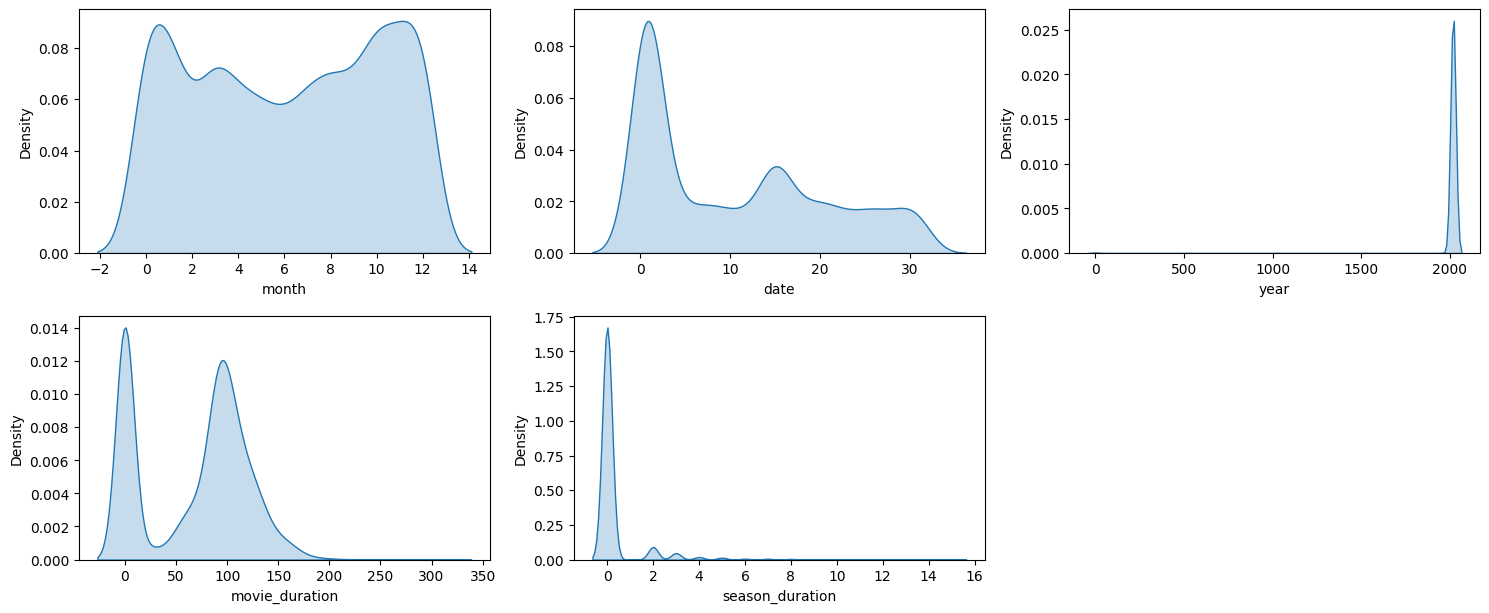

In [53]:
## Proportion of count data on numerical columns
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(15, 15))

for i in range(len(numeric_features)):
    plt.subplot(5, 3, i+1)
    sns.kdeplot(x=df_copy[numeric_features[i]],fill=True,)
    plt.xlabel(numeric_features[i])
    plt.tight_layout()

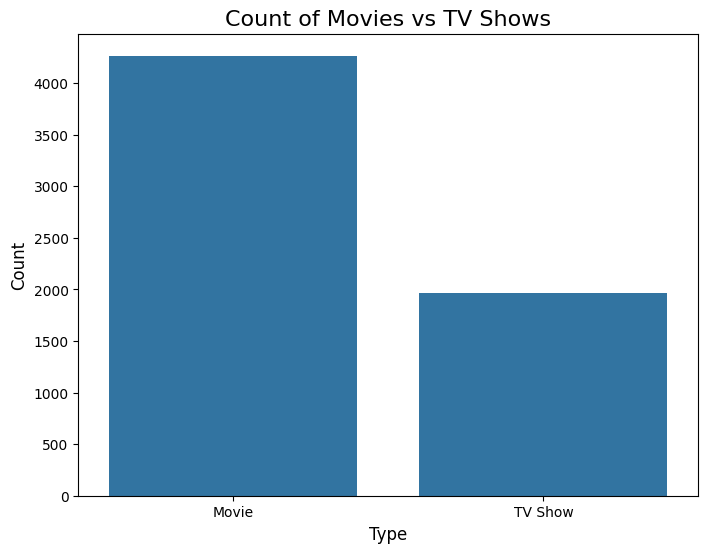

In [55]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='type',)
plt.title('Count of Movies vs TV Shows', fontsize=16)
plt.xlabel('Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

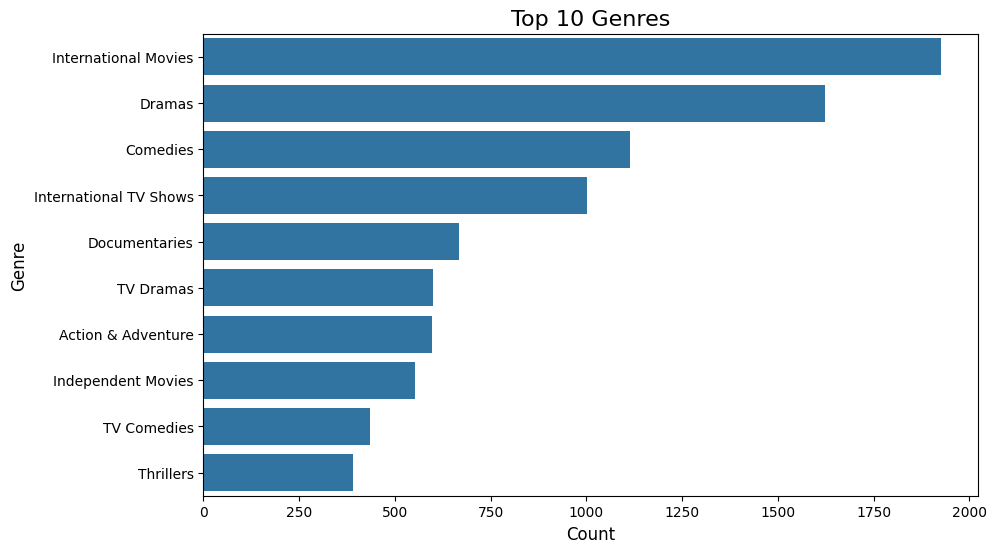

In [57]:
plt.figure(figsize=(10, 6))
genres = df['listed_in'].str.split(', ').explode()
top_genres = genres.value_counts().head(10)
sns.barplot(x=top_genres.values, y=top_genres.index,)
plt.title('Top 10 Genres', fontsize=16)
plt.xlabel('Count', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.show()

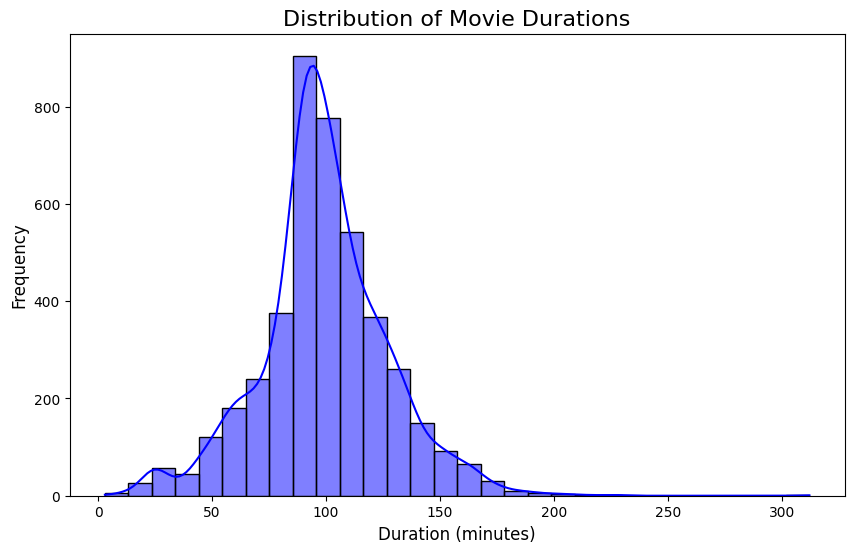

In [58]:
plt.figure(figsize=(10, 6))
sns.histplot(df[df['type'] == 'Movie']['movie_duration'], bins=30, kde=True, color='blue')
plt.title('Distribution of Movie Durations', fontsize=16)
plt.xlabel('Duration (minutes)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

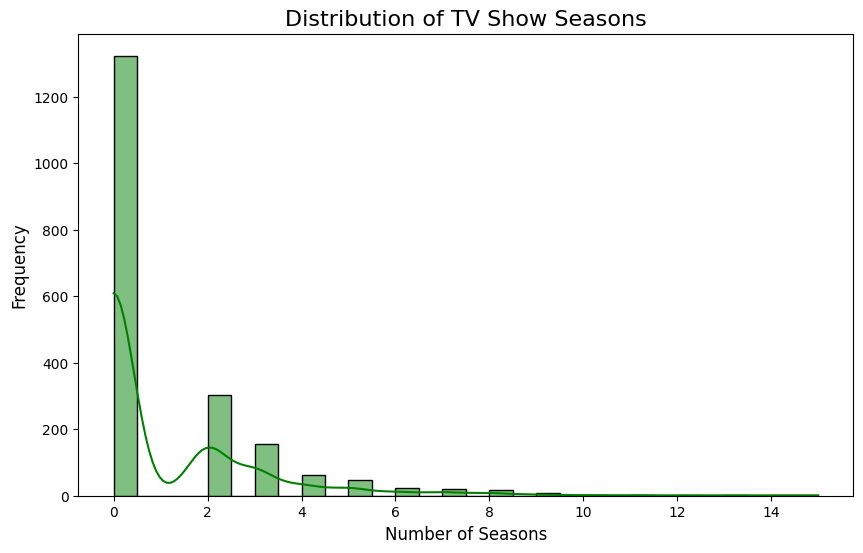

In [59]:
plt.figure(figsize=(10, 6))
sns.histplot(df[df['type'] == 'TV Show']['season_duration'], bins=30, kde=True, color='green')
plt.title('Distribution of TV Show Seasons', fontsize=16)
plt.xlabel('Number of Seasons', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

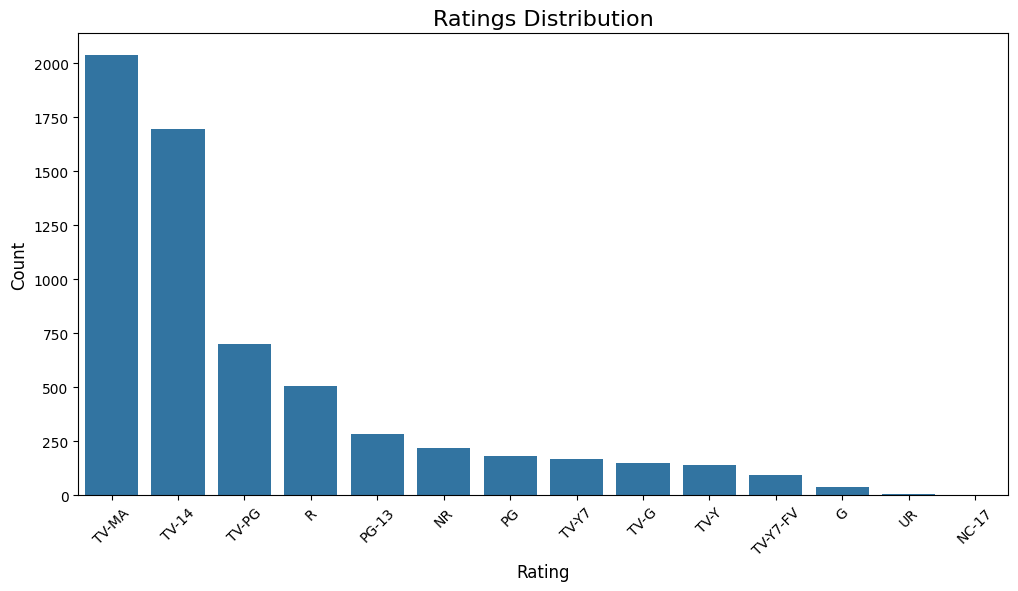

In [61]:
plt.figure(figsize=(12, 6))
rating_counts = df['rating'].value_counts()
sns.barplot(x=rating_counts.index, y=rating_counts.values,)
plt.title('Ratings Distribution', fontsize=16)
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.show()